# ***Proactive Threat Forecaster***

#### The goal of this project is to predict a system’s probability of getting infected by various families of malware, based on different properties of that system. The telemetry data containing these properties and the system infections was generated by threat reports collected by system's antivirus software.

# ***Importing Libraries***

In [2]:
# Essential libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, chi2


# Machine learning models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Suppress warnings -- used to remove Non-critical warnings/messages
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ***Loading the Dataset***

In [ ]:
# Load the training data
train_data = pd.read_csv('C:\Users\harin\OneDrive\Documents\Clg\Major Project\Implementation\Dataset\train.csv') # copy file path of 'train.csv' from ur local system

In [ ]:
# Load the test data
test_data = pd.read_csv('C:\Users\harin\OneDrive\Documents\Clg\Major Project\Implementation\Dataset\test.csv') # copy file path of 'test.csv' from ur local system
X_test = test_data.drop(['target'], axis=1, errors='ignore')  # Exclude 'target'

# ***Exploratory Data Analysis*** 

## ***1. Exploring the data***

In [5]:
print(f"Training Dataset contains {train_data.shape[0]} rows and {train_data.shape[1]} columns.")
print(f"Test Dataset contains {test_data.shape[0]} rows and {test_data.shape[1]} columns.")

Training Dataset contains 100000 rows and 76 columns.
Test Dataset contains 10000 rows and 75 columns.


### ***Information of Training Dataset***

In [6]:
#Displaying information of datasets
print("Given Training dataset:")
train_data.info()

Given Training dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  Has

### ***Total Number of Null Values in Dataset***

In [7]:
train_data.isna().sum().sum()

6533

### ***Total Number of Null Values in each Column***

In [8]:
train_data.isna().sum()

MachineID             0
ProductName           0
EngineVersion         0
AppVersion            0
SignatureVersion      0
                   ... 
IsGamer             559
RegionIdentifier    559
DateAS                0
DateOS               24
target                0
Length: 76, dtype: int64

### ***.head()***

In [9]:
#Displaying first 10rows of datasets
print("Sample of Dataset:")
train_data.head(n=10)

Sample of Dataset:


,MachineID,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,...,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,f541bae429089117c4aac39c90dd3416,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,0,7.0,0,53447.0,1.0,...,0,0.0,1,0,1.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,dc2b14d9ce3a0ce4050bb640190f2ca5,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,0,7.0,0,53447.0,1.0,...,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,fd20c5f010e9c5f91ad1c6b3e0da68a0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,0,7.0,0,53447.0,1.0,...,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1
3,38711eae85eb77a72ec5dfdf27eb2a76,win8defender,1.1.15200.1,4.12.17007.18011,1.275.1141.0,0,7.0,0,46413.0,2.0,...,1,0.0,0,0,0.0,0.0,12.0,2018-09-14 00:32:00,2018-01-03,1
4,32607c9a543a9214e2c7e45800ed4849,win8defender,1.1.15200.1,4.13.17134.228,1.275.1283.0,0,7.0,0,40466.0,2.0,...,0,0.0,0,0,0.0,1.0,7.0,2018-09-15 19:34:00,2018-09-11,0
5,22f549ef938e3a943854d49c853ba918,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1338.0,0,7.0,0,53447.0,1.0,...,0,0.0,0,0,0.0,1.0,4.0,2018-09-17 02:29:00,2018-09-11,0
6,d197d1b86b9071b50a655bb3b31cc828,win8defender,1.1.15200.1,4.18.1807.18075,1.275.182.0,0,7.0,0,53447.0,1.0,...,0,0.0,0,0,0.0,0.0,11.0,2018-08-26 09:33:00,2018-08-14,0
7,8e3a7d3fe18b946443f0777060f82ab7,win8defender,1.1.15100.1,4.18.1807.18075,1.273.738.0,0,7.0,0,53447.0,1.0,...,0,0.0,0,0,0.0,0.0,1.0,2018-08-02 16:51:00,2018-07-16,1
8,bdb0b0d016466c16b3c58ce39da702e1,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1498.0,0,7.0,0,53447.0,1.0,...,0,0.0,0,0,0.0,0.0,1.0,2018-08-16 11:38:00,2018-07-10,0
9,44f4b3df4c9ecc13c4a8f3b61f7a18c8,win8defender,1.1.15200.1,4.18.1807.18075,1.275.36.0,0,7.0,0,53447.0,1.0,...,1,0.0,0,0,0.0,1.0,1.0,2018-08-23 12:13:00,2018-07-16,1


### ***.describe()***

In [10]:
# describe() method in Pandas is a powerful tool for quickly obtaining an overview of a DataFrame’s numeric features
print("Statistical Observations:")
train_data.describe()

Statistical Observations:


,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,...,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target
count,100000.0,99934.000000,100000.000000,99924.000000,99924.000000,99924.000000,100000.000000,100000.000000,99377.000000,100000.000000,...,99624.000000,99666.000000,100000.000000,99980.000000,100000.000000,100000.000000,99866.000000,99441.000000,99441.000000,100000.000000
mean,0.0,6.848430,0.017620,47975.710440,1.326528,1.018264,0.996780,108.078790,81029.938587,169.741630,...,401.987613,32942.648044,0.495690,0.003841,0.128470,0.040580,0.058398,0.296668,7.875866,0.505250
std,0.0,1.015166,0.131566,13803.321533,0.520681,0.155291,0.056654,63.062151,48944.027074,89.188929,...,221.318891,21151.970827,0.499984,0.061855,0.334614,0.197316,0.234496,0.456791,4.562533,0.499975
min,0.0,0.000000,0.000000,39.000000,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,...,2.000000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.0,7.000000,0.000000,49480.000000,1.000000,1.000000,1.000000,51.000000,36694.000000,89.000000,...,142.000000,13020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,0.0,7.000000,0.000000,53447.000000,1.000000,1.000000,1.000000,97.000000,82373.000000,181.000000,...,500.000000,33066.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000
75%,0.0,7.000000,0.000000,53447.000000,2.000000,1.000000,1.000000,162.000000,122835.000000,267.000000,...,556.000000,52357.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,1.000000
max,0.0,8.000000,1.000000,70490.000000,5.000000,4.000000,1.000000,222.000000,167957.000000,296.000000,...,1083.000000,72091.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.000000,1.000000


#### Note- Describe gives Statistical observations of only Numerical Features.

## ***2. Visualization***

In [11]:
numerical_features = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train_data.select_dtypes(include=['object', 'category']).columns.tolist()

# Print count of numerical and categorical columns
print("Number of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

Number of Numerical Features: 48
Number of Categorical Features: 28


## Correlation Heatmap with Target Column

In [12]:
# Keep only numerical columns
numeric_df = train_data.select_dtypes(include=['int64', 'float64'])

# Computes Pearson correlation matrix
correlation_matrix = numeric_df.corr()    
correlation_matrix

,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,...,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target
IsBetaUser,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RealTimeProtectionState,NaN,1.000000,-0.901426,0.107907,-0.184396,-0.001299,-0.001035,0.010743,-0.001671,0.013603,...,0.010112,0.008421,-0.015123,0.007044,0.009187,0.003635,0.019879,-0.023005,-0.009479,0.049012
IsPassiveModeEnabled,NaN,-0.901426,1.000000,-0.111384,0.195344,0.023414,0.004929,-0.010327,-0.001968,-0.013213,...,-0.009343,-0.008979,0.017269,-0.007088,-0.005307,-0.000579,-0.016466,0.025863,0.007966,-0.041997
AntivirusConfigID,NaN,0.107907,-0.111384,1.000000,-0.647222,-0.115021,0.059230,0.008457,-0.000666,0.017477,...,-0.009623,-0.020802,-0.044251,0.023157,0.034506,0.033627,0.060264,-0.026385,-0.008294,0.118304
NumAntivirusProductsInstalled,NaN,-0.184396,0.195344,-0.647222,1.000000,0.273791,0.010237,-0.017957,0.003512,-0.042795,...,0.054231,0.047223,0.210308,-0.035076,-0.011100,-0.029814,-0.075055,0.008620,0.028845,-0.151375
NumAntivirusProductsEnabled,NaN,-0.001299,0.023414,-0.115021,0.273791,1.000000,-0.020977,-0.014795,0.006448,-0.022393,...,0.015469,0.003158,0.037019,-0.009299,0.000088,-0.005245,-0.018295,-0.009562,0.000937,-0.041547
HasTpm,NaN,-0.001035,0.004929,0.059230,0.010237,-0.020977,1.000000,0.007648,-0.005940,0.005161,...,-0.004301,-0.001458,0.035167,0.000676,0.011799,0.009900,0.013294,0.028136,-0.003924,0.007658
CountryID,NaN,0.010743,-0.010327,0.008457,-0.017957,-0.014795,0.007648,1.000000,-0.000624,0.597061,...,-0.018788,0.021881,-0.013022,-0.005375,0.004135,-0.008432,-0.008681,0.017307,-0.117528,0.004616
CityID,NaN,-0.001671,-0.001968,-0.000666,0.003512,0.006448,-0.005940,-0.000624,1.000000,-0.060922,...,-0.025710,0.019929,0.010010,-0.001436,-0.015534,-0.000909,-0.003993,0.004718,-0.052817,-0.004596
GeoRegionID,NaN,0.013603,-0.013213,0.017477,-0.042795,-0.022393,0.005161,0.597061,-0.060922,1.000000,...,-0.003138,0.004449,-0.067412,0.010703,0.023614,-0.002761,-0.009481,-0.002651,-0.022153,0.002802


#### Note- Instead of making heatmap of col-col, I've produced heatmap for Col-Target

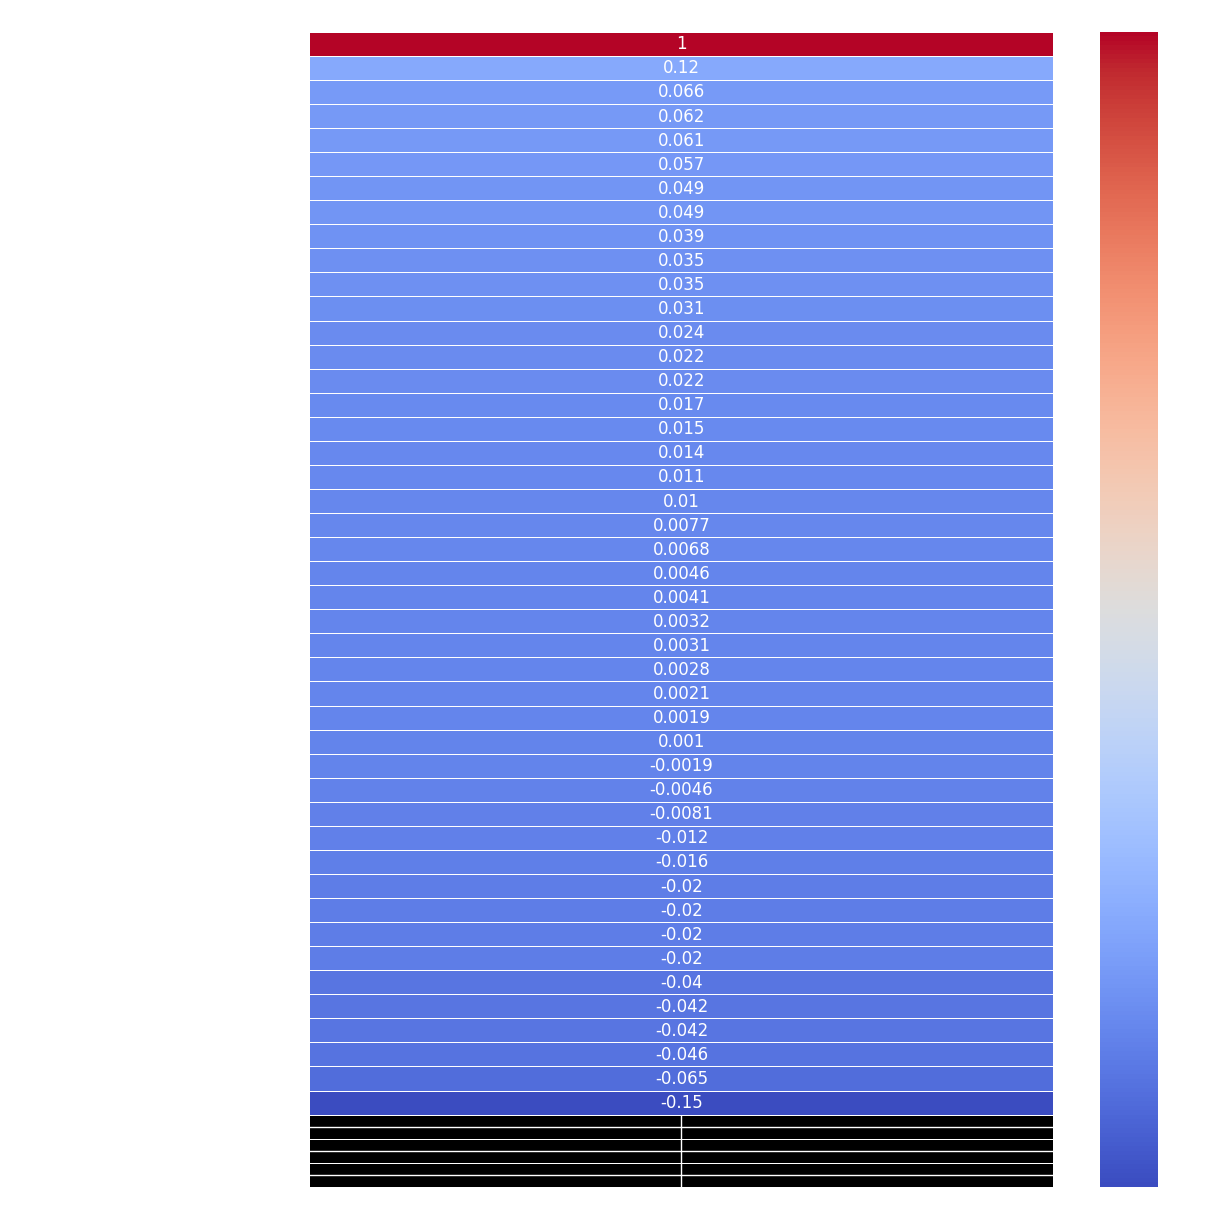

In [13]:
plt.figure(figsize=(12, 15))
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# Plot correlation of features with the target
sns.heatmap(correlation_matrix[['target']].sort_values(by='target', ascending=False), 
            annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation with Target")
plt.show()

#### Note- Three features- { IsBetaUser, AutoSampleSubmissionEnabled and IsFlightDisabled } have zero corr with Target, hence to reduce noise by these three columns, we can eliminate them from model training.

In [14]:
# Identify features with NaN correlation with the target feature
nan_corr_features = correlation_matrix['target'].isna()
nan_corr_features_list = correlation_matrix.columns[nan_corr_features].tolist()
print("Features with NaN correlation:", nan_corr_features_list)

Features with NaN correlation: ['IsBetaUser', 'AutoSampleSubmissionEnabled', 'IsFlightsDisabled']


In [15]:
df = train_data.copy()

# Removing unwanted columns
df = df.drop(columns=['IsBetaUser', 'AutoSampleSubmissionEnabled', 'IsFlightsDisabled'])

#### ***Output Interpretation:***
#### 1. The heatmap shows how strongly each feature is correlated with the target variable (target).
#### 2. Red shades indicate positive correlation (higher feature value → higher probability of threat).
#### 3. Blue shades indicate negative correlation (higher feature value → lower probability of threat).
#### 4. White/neutral colors indicate very weak or no correlation.
   
#### ***Observations from the Heatmap:***
#### 1. TotalPhysicalRAMMB (0.12) has the highest positive correlation with the target.
#### 2. Features like NumAntivirusProductsInstalled (-0.15) show negative
#### 3. Strong Negative Correlation, meaning higher values of these features may reduce the probability of a malware threat.
#### 4. Many features have very low correlation values (close to 0), meaning they do not significantly impact whether a system gets infected or not.

##  Distribution of Numerical Features

#### Note- Instead of checking distributions of entire numerical columns, it's better to examin top 10 numerical features of dataset, one with itself and other with the Target variable.

In [16]:
# Select numerical features excluding target
numerical_features = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'target' in numerical_features:
    numerical_features.remove('target')  # Exclude target column

# Drop columns with all NaN values
df_num = train_data[numerical_features].dropna(axis=1, how='all')

# Drop constant columns (zero variance)
df_num = df_num.loc[:, df_num.nunique() > 1]

# Check if df_cleaned is empty after filtering
if df_num.shape[1] == 0:
    print("No valid numerical features for correlation analysis.")
else:
    # Calculate correlation with target
    correlation = df_num.corrwith(train_data['target']).abs()

    # Select top 10 most correlated features
    top_features = correlation.nlargest(10).index.tolist()
    print("Top 10 Numerical Features:", top_features)

Top 10 Numerical Features: ['NumAntivirusProductsInstalled', 'AntivirusConfigID', 'TotalPhysicalRAMMB', 'IsAlwaysOnAlwaysConnectedCapable', 'IsSystemProtected', 'IsGamer', 'ProcessorCoreCount', 'PrimaryDiskCapacityMB', 'RealTimeProtectionState', 'IsTouchEnabled']


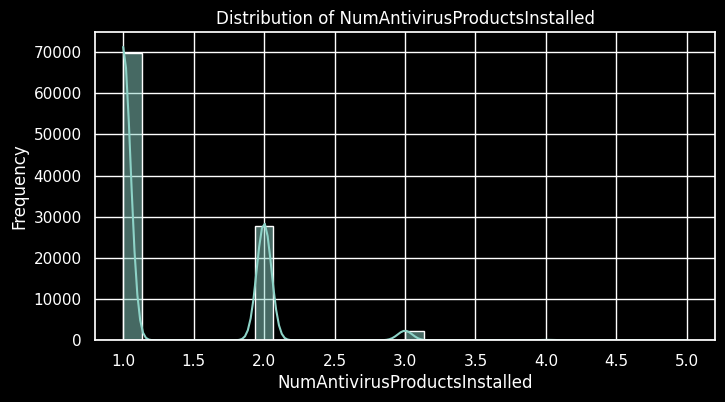

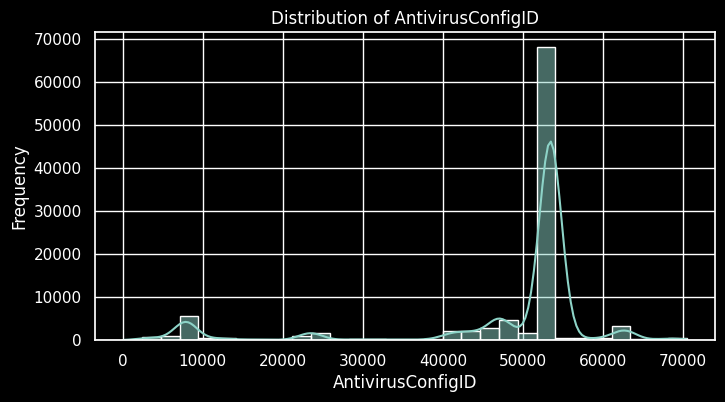

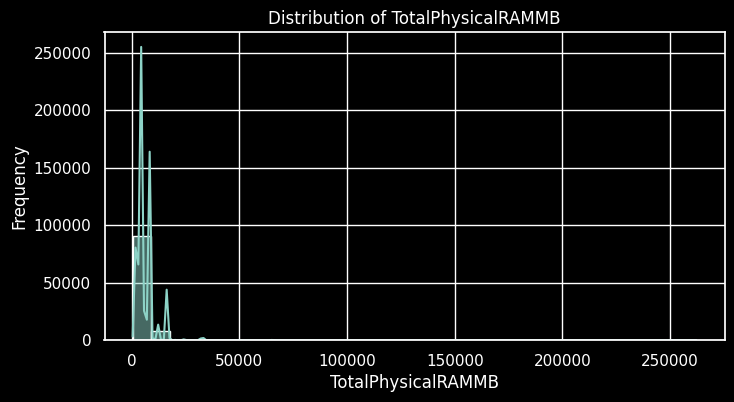

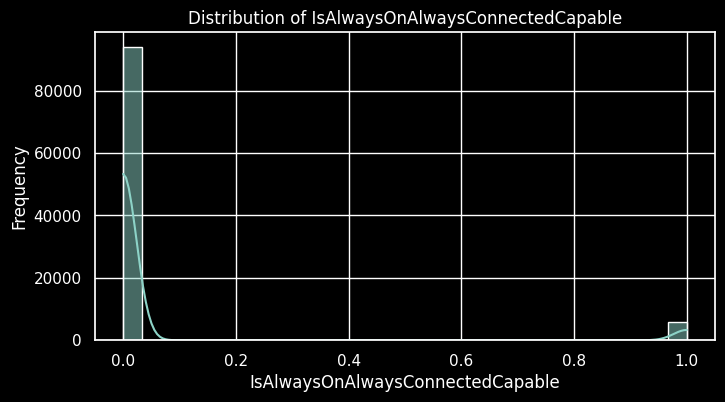

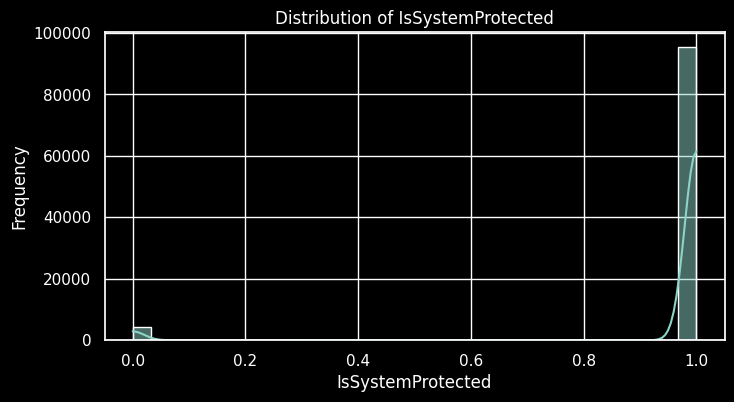

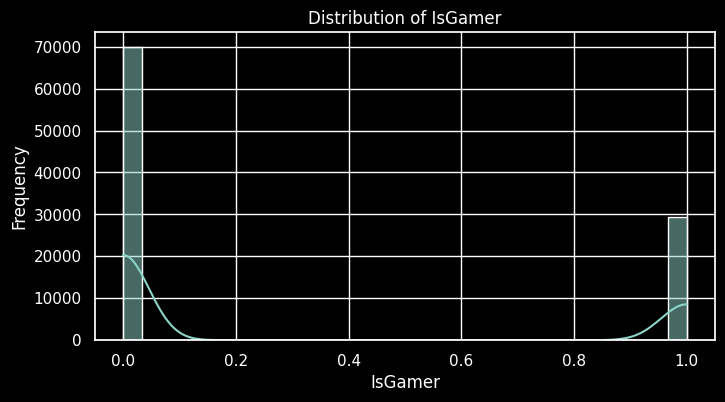

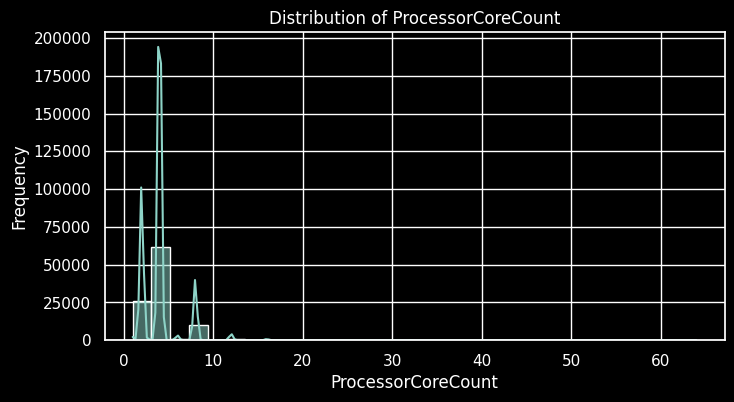

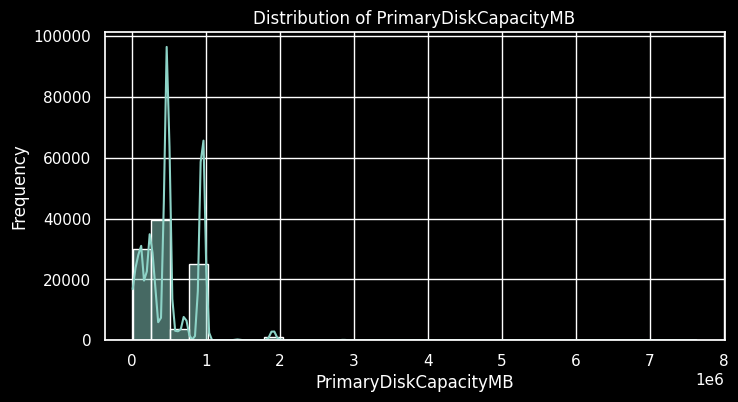

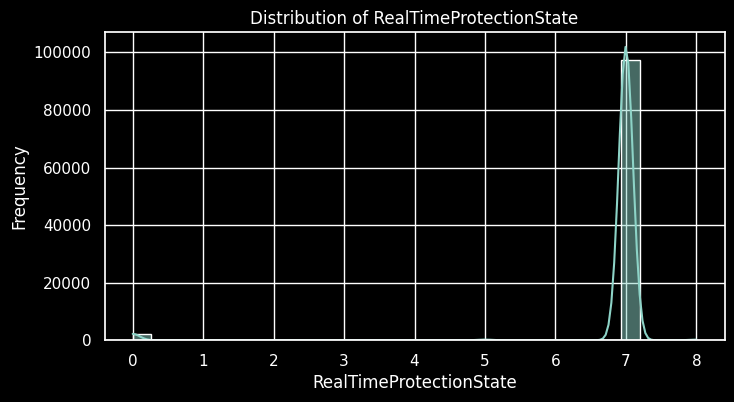

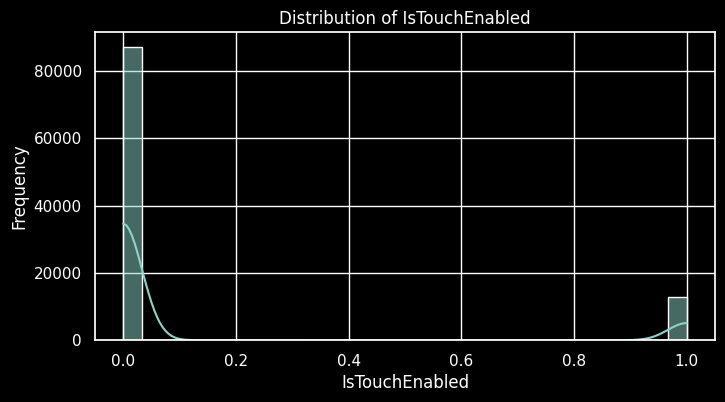

In [17]:
# Plot distributions for these features
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')
for feature in top_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_data[feature], kde=True, bins=30) #Kernel Density Estimate (KDE) line
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

### ***Observation:***

#### ***GRAPH1: Distribution of NumAntivirusProductsInstalled***

    1. Most systems have only 1 or 2 antivirus products installed.
    2. Very few systems have 3 or more antivirus products.
    3. The KDE curve shows two peaks, suggesting a bimodal distribution (two common values).
    
#### ***GRAPH2: Distribution of AntivirusConfigID***

    1. A very high peak around 50,000, meaning most systems share a common antivirus configuration.
    2. Other values are spread out, but with significantly lower frequency.
    3. Indicates that a majority of systems use a few dominant antivirus configurations, while others are rare.

#### ***For most of the features, the distribution is Bimodal Distribution (2 mode values) and Bernoulli Distribution (0 and 1)***

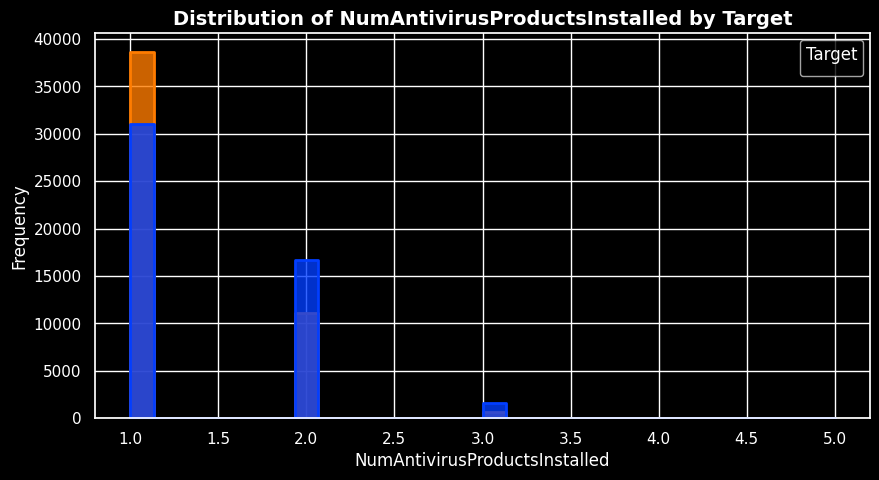

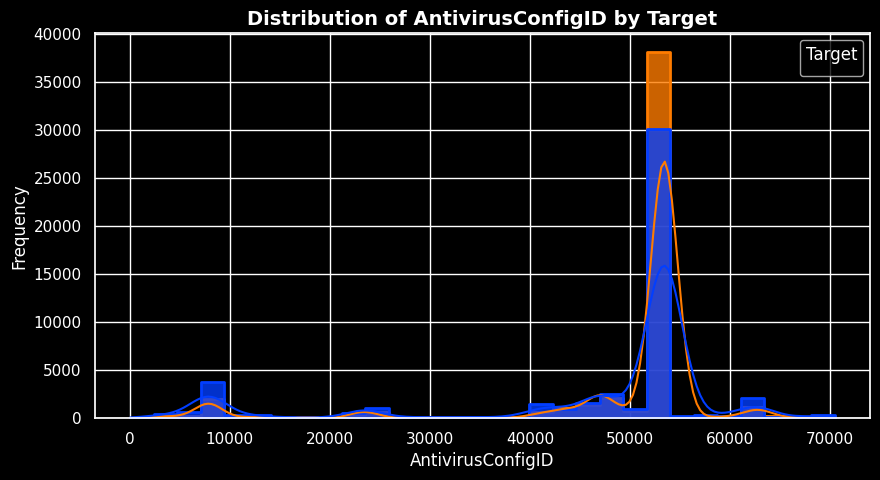

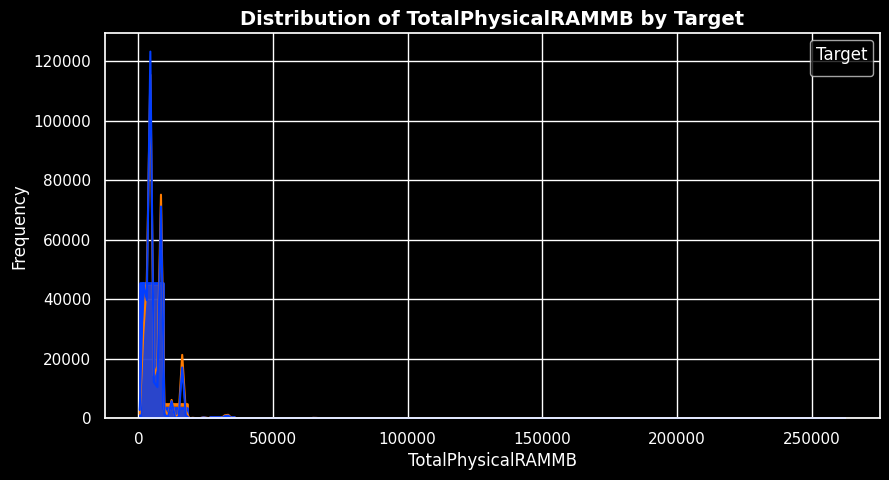

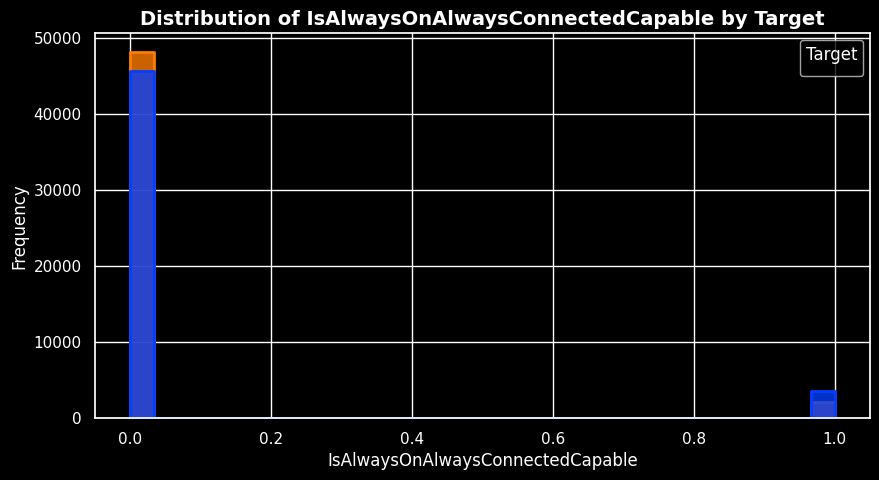

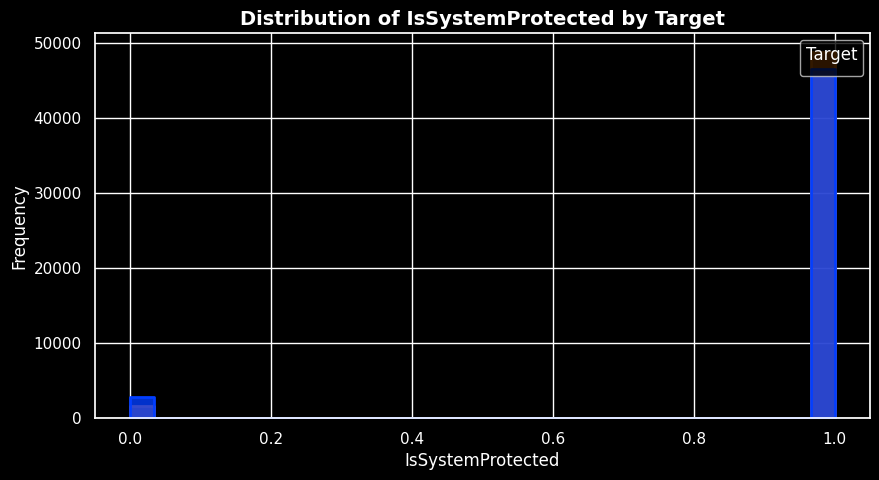

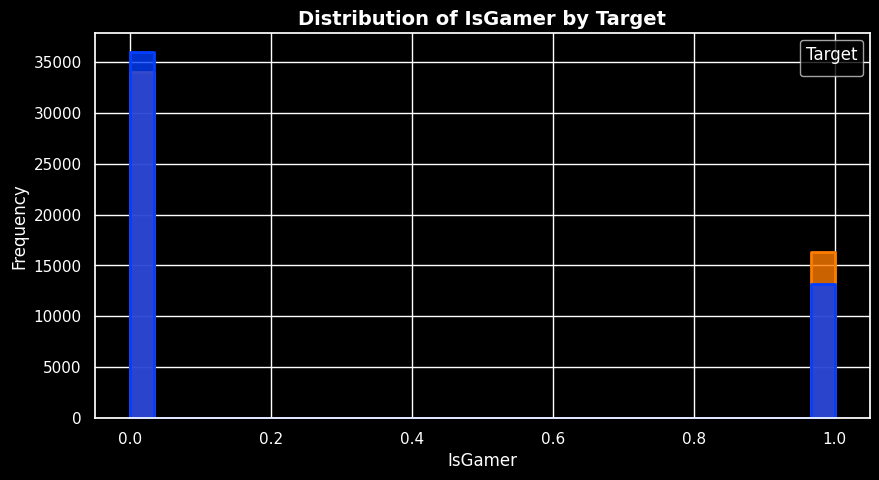

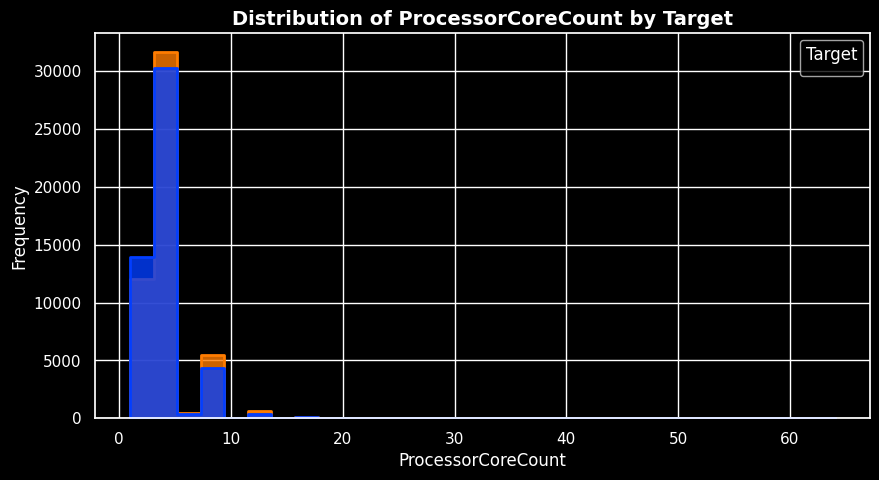

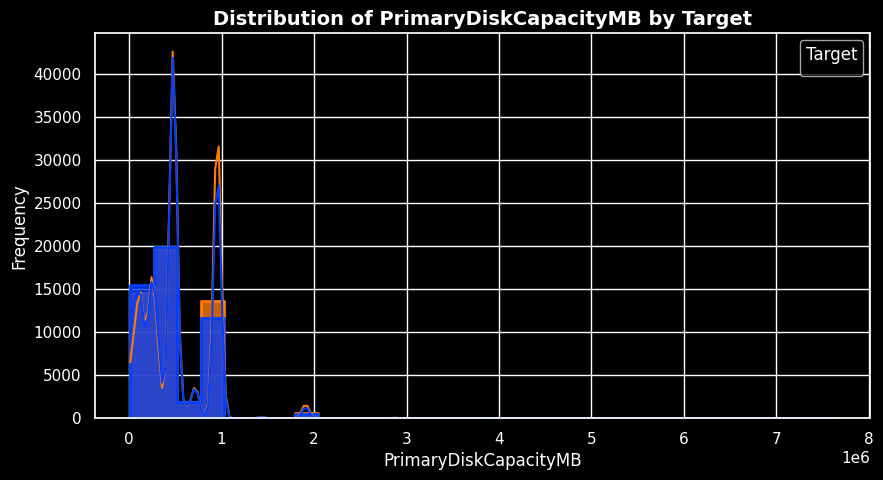

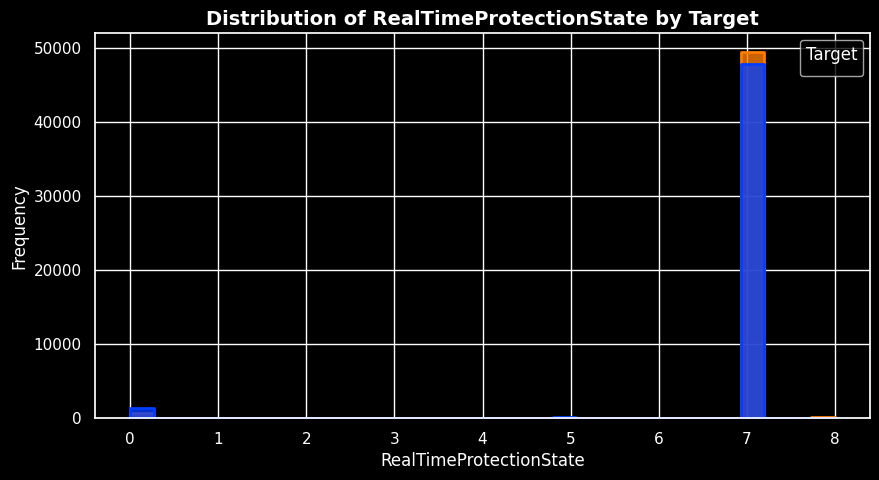

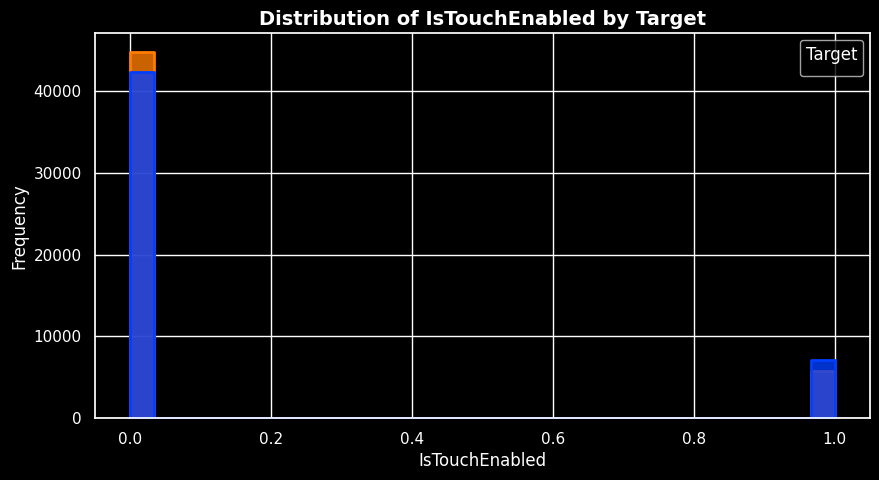

In [18]:
# Select numerical features
numerical_features = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'target' in numerical_features:
    numerical_features.remove('target')  # Exclude target column

# Drop features with constant values
df_filtered = train_data[numerical_features].loc[:, train_data[numerical_features].nunique() > 1]

# Compute correlation with target & select top 10 most important features
top_features = df_filtered.corrwith(train_data['target']).abs().nlargest(10).index.tolist()

# Setting the theme
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# Plot histograms for the top 5 features
for feature in top_features:
    plt.figure(figsize=(10, 5))

    # Check if the feature is discrete (low unique values)
    is_discrete = df_filtered[feature].nunique() < 20  # Adjust threshold if needed

    # Plot histogram
    sns.histplot(
        data=train_data, x=feature, hue='target',
        kde=not is_discrete,  # Enable Kernel Density Estimation only for continuous data
        bins=30, element='step', palette="bright",  # Alternative: "pastel", "deep", "tab10"
        linewidth=2, alpha=0.8
    )
    plt.title(f"Distribution of {feature} by Target", fontsize=14, fontweight='bold', color='white')
    plt.xlabel(feature, fontsize=12, color='white')
    plt.ylabel("Frequency", fontsize=12, color='white')
    plt.legend(title="Target", fontsize=10, title_fontsize=12)
    plt.show()

### ***Observations:***

 

| SNo. | GraphNo. | Analysis | Relation with TargetVariable |
|------|---------|----------|------------------------------|
| 1 | 1 | - Majority of systems have **IsSystemProtected = 1**. <br> - Very few systems have **IsSystemProtected = 0**. | Malware infections seem **more common when IsSystemProtected = 0**, indicating protection reduces risk. |
| 2 | 2 | - Most systems are **not gaming systems (IsGamer = 0)**. <br> - A smaller proportion of systems are gaming PCs (IsGamer = 1). | Gaming systems seem **slightly more vulnerable to malware**, but the effect is minor. |
| 3 | 3 | - Majority of systems have **low processor core counts** (mainly 2-8 cores). <br> - Very few systems have **higher core counts (16+ cores)**. | No strong correlation; **both low and high-core systems have similar malware trends**. |
| 4 | 4 | - Most systems have **PrimaryDiskCapacityMB between 0.5M - 1.5M MB**. <br> - Few systems have **extremely large disk capacities (>3M MB)**. | Malware risk is **not strongly dependent on disk capacity**, as both small and large capacities show infections. |
| 5 | 5 | - Majority of systems have **RealTimeProtectionState = 7**. <br> - Very few systems have **RealTimeProtectionState = 0 or lower values**. | Malware infection is **higher in systems where real-time protection is off or at low settings**. |
| 6 | 6 | - Most systems are **not touch-enabled (IsTouchEnabled = 0)**. <br> - A smaller percentage have **touch-enabled screens (IsTouchEnabled = 1)**. | No clear relation between **touchscreen devices and malware infections**. |
| 7 | 7 | - Most systems run **64-bit OS architectures**. <br> - A small percentage have **32-bit architectures**. | **32-bit systems might be slightly more prone to malware infections**, possibly due to outdated security measures. |
| 8 | 8 | - The majority of devices have **SecureBoot = 1** (enabled). <br> - A small portion have **SecureBoot = 0** (disabled). | Systems with **SecureBoot disabled show higher infection rates**, suggesting it plays a role in security. |
| 9 | 9 | - Most systems use **up-to-date Windows versions**. <br> - A smaller number of systems are on **older OS builds**. | **Older OS versions are more vulnerable to malware infections** compared to newer builds. |
| 10 | 10 | - Majority of systems have **FirewallEnabled = 1**. <br> - A few systems have **FirewallDisabled (FirewallEnabled = 0)**. | Malware infections are **more common when firewalls are disabled**, highlighting its role in protection. |


In [19]:
print(train_data.shape," ",df.shape," ")

(100000, 76)   (100000, 73)  


## Categorical Feature Analysis

In [20]:
categorical_features = train_data.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Features:", categorical_features)

Categorical Features: ['MachineID', 'ProductName', 'EngineVersion', 'AppVersion', 'SignatureVersion', 'PlatformType', 'Processor', 'OSVersion', 'OsPlatformSubRelease', 'OSBuildLab', 'SKUEditionName', 'MDC2FormFactor', 'DeviceFamily', 'PrimaryDiskType', 'ChassisType', 'PowerPlatformRole', 'NumericOSVersion', 'OSArchitecture', 'OSBranch', 'OSEdition', 'OSSkuFriendlyName', 'OSInstallType', 'AutoUpdateOptionsName', 'OSGenuineState', 'LicenseActivationChannel', 'FlightRing', 'DateAS', 'DateOS']


MachineID has 99835 unique values
 
ProductName has 2 unique values


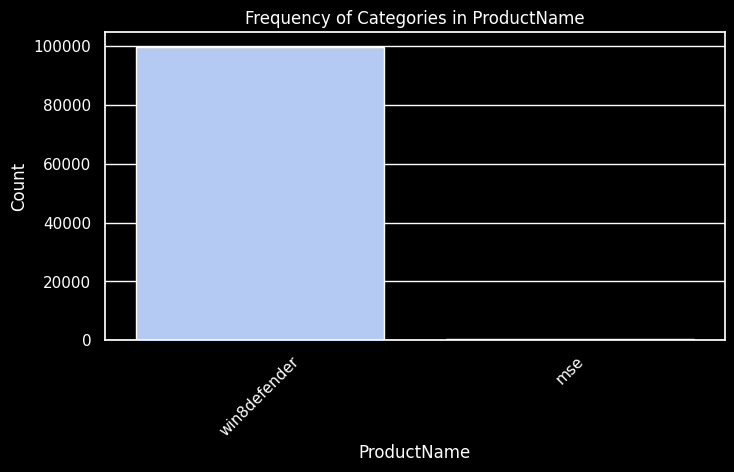

EngineVersion has 37 unique values
 
AppVersion has 69 unique values
 
SignatureVersion has 2735 unique values
 
PlatformType has 4 unique values


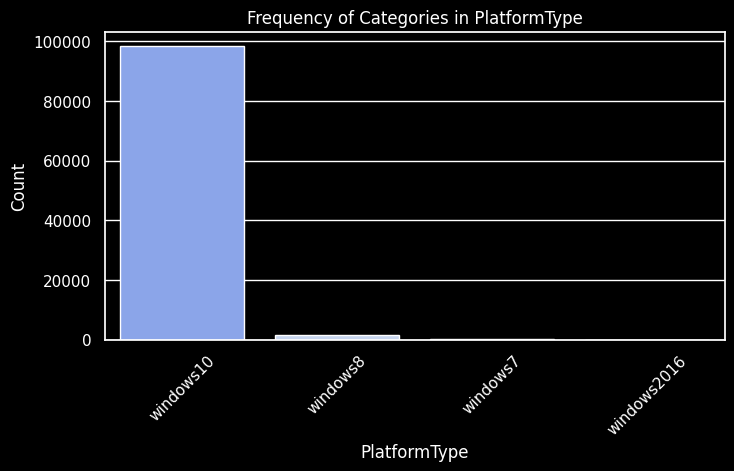

Processor has 3 unique values


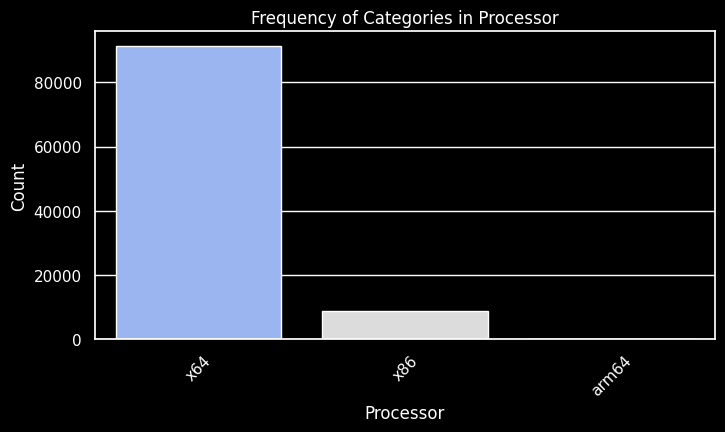

OSVersion has 7 unique values


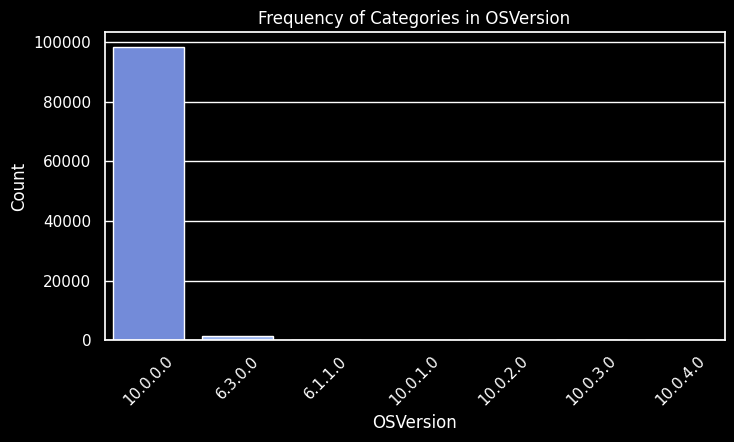

OsPlatformSubRelease has 9 unique values


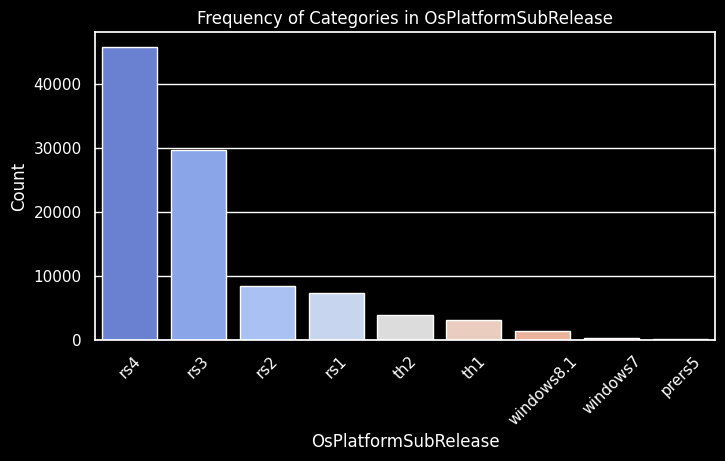

OSBuildLab has 281 unique values
 
SKUEditionName has 8 unique values


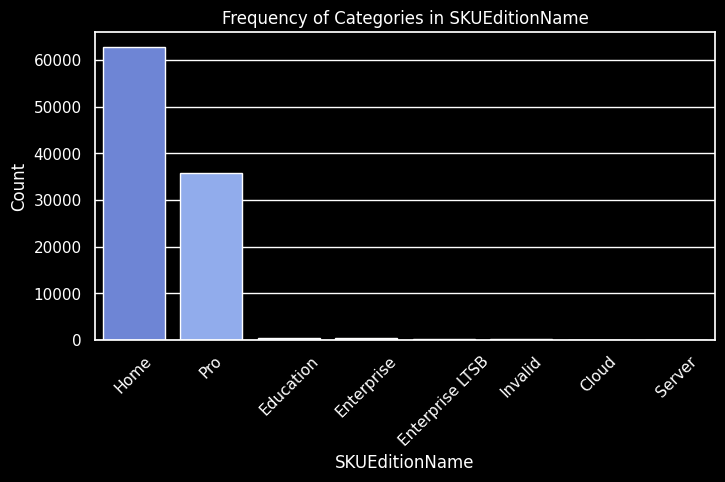

MDC2FormFactor has 11 unique values


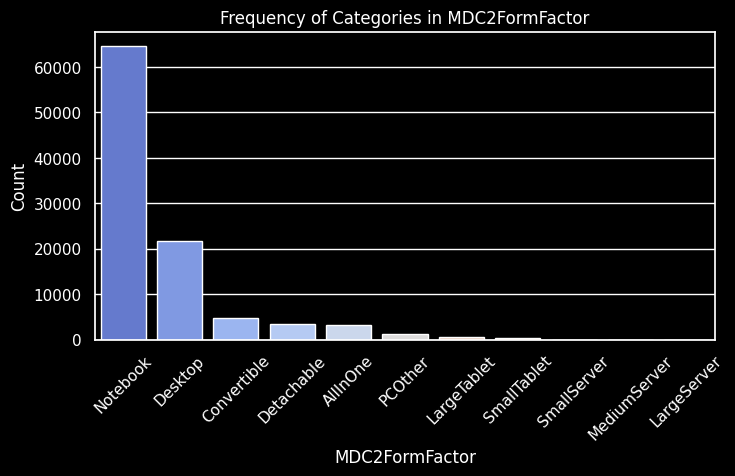

DeviceFamily has 2 unique values


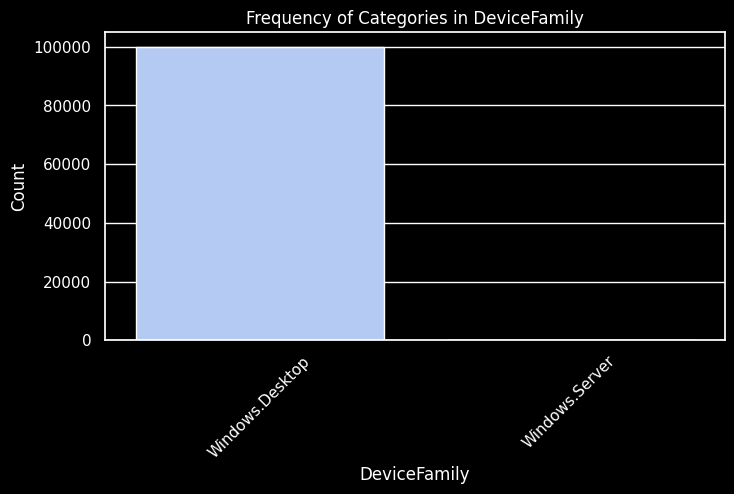

PrimaryDiskType has 4 unique values


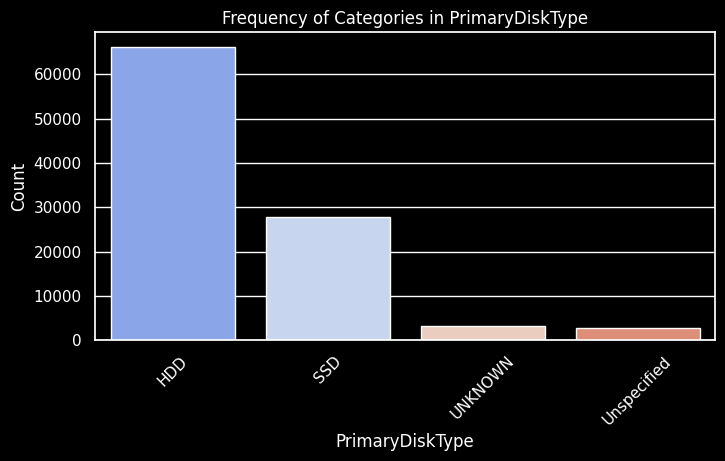

ChassisType has 28 unique values
 
PowerPlatformRole has 9 unique values


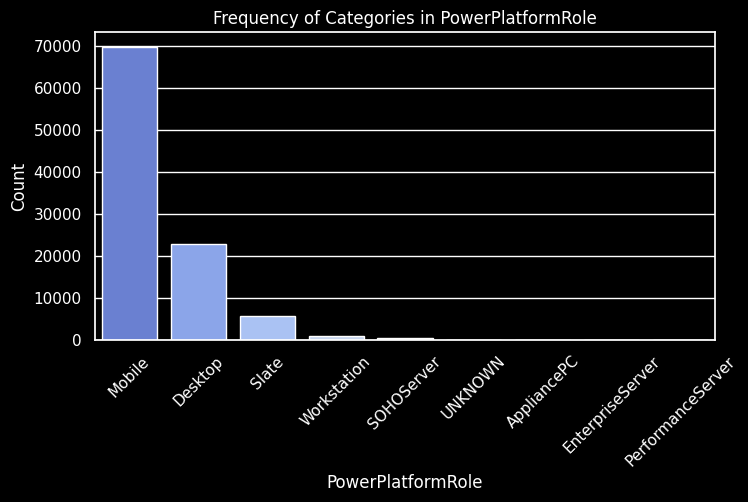

NumericOSVersion has 221 unique values
 
OSArchitecture has 3 unique values


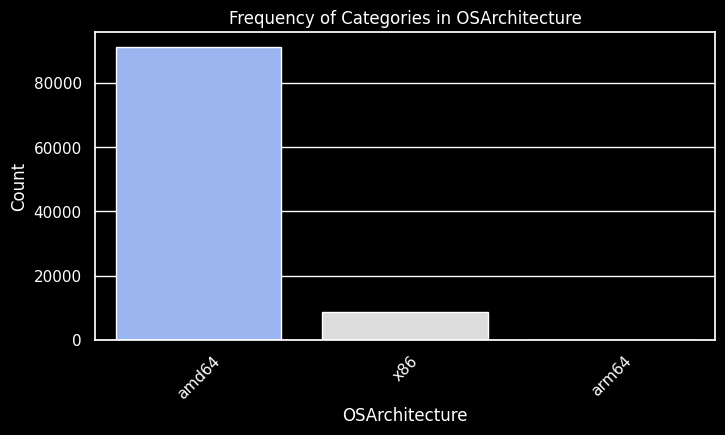

OSBranch has 13 unique values


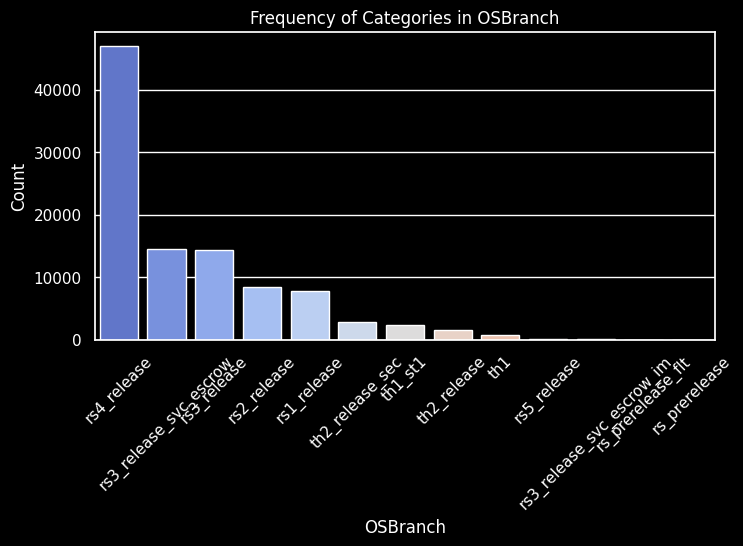

OSEdition has 20 unique values
 
OSSkuFriendlyName has 18 unique values


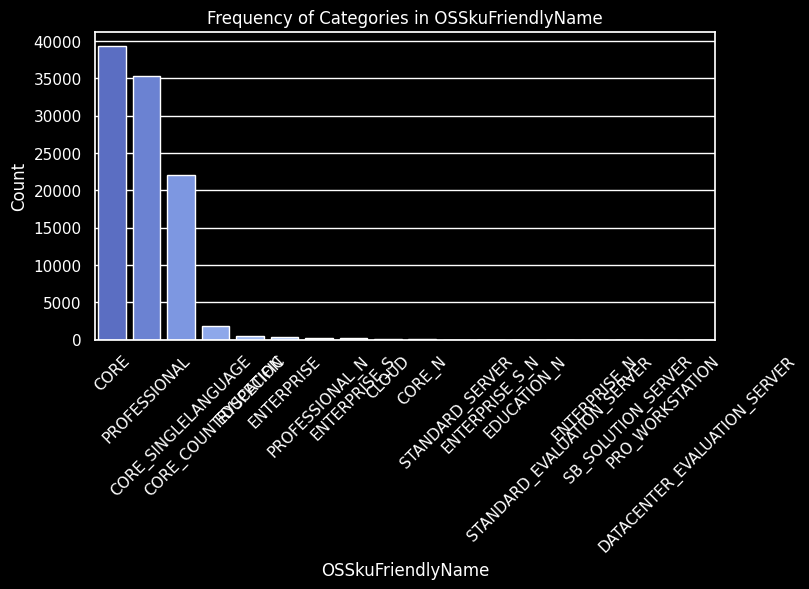

OSInstallType has 9 unique values


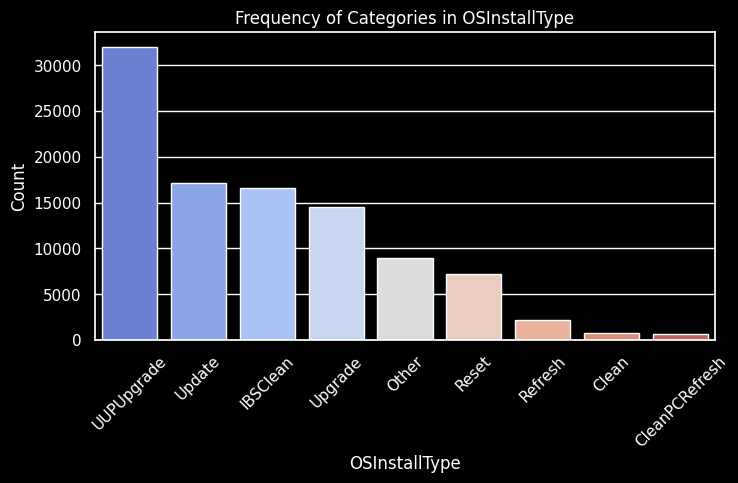

AutoUpdateOptionsName has 6 unique values


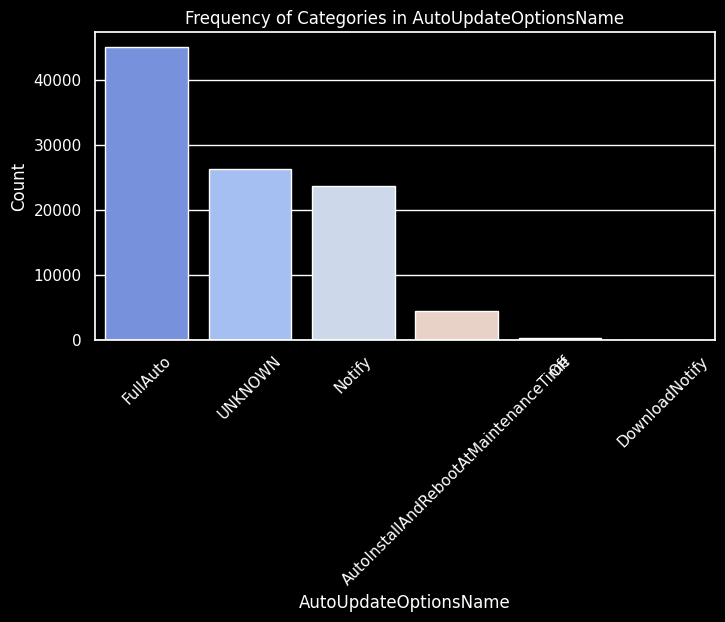

OSGenuineState has 4 unique values


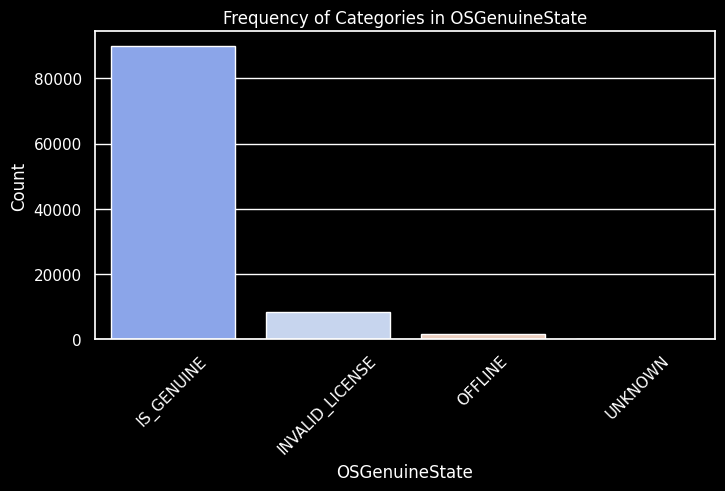

LicenseActivationChannel has 6 unique values


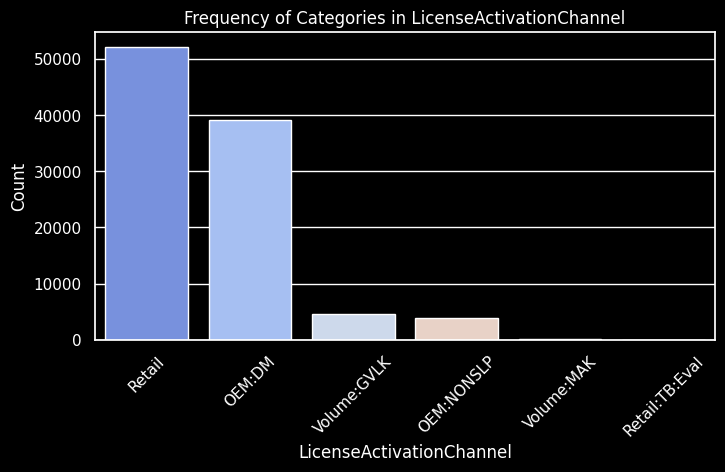

FlightRing has 7 unique values


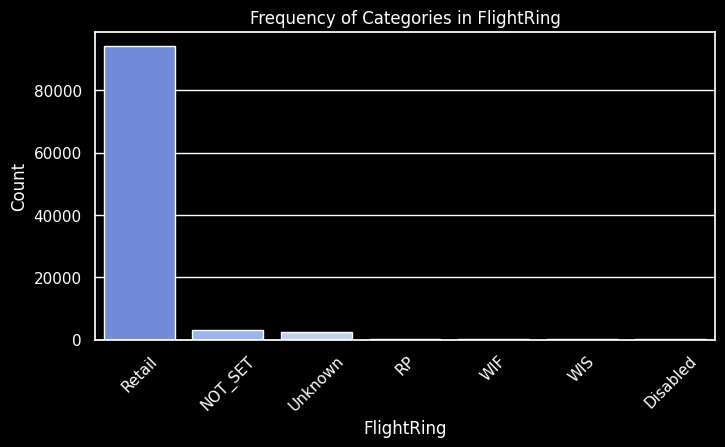

DateAS has 2695 unique values
 
DateOS has 112 unique values
 


In [21]:
# Analysing categorical features (Limit to < 20 unique categories)
for feature in categorical_features:
    unique_values = train_data[feature].nunique()
    
    print(f"{feature} has {unique_values} unique values")

    # Plotting only if unique values are manageable (e.g., < 20)
    if unique_values < 20:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=train_data, x=feature, order=train_data[feature].value_counts().index, palette='coolwarm')
        plt.title(f"Frequency of Categories in {feature}")
        plt.xlabel(feature)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()
    else:
        print(" ")
        # print(f"Skipping plot for '{feature}' due to high cardinality.")

#### Carefully note, there exists some unwanted bins like- 'Unknown','UNKNOWN', 'Unspecified'

#### ***Observations:***

#### 1️⃣ ProductName Distribution

#### 1. Most common: win8defender
#### 2. Rare occurrence: mse
   
#### Inference:
#### 1. Majority of devices are using win8defender.
#### 2. mse is extremely rare, meaning it may not contribute significantly to malware infection predictions.

#### 2️⃣ PlatformType Distribution
#### 1. Dominant OS: windows10 (overwhelming majority)
#### 2. Minor presence: windows8, windows7, windows2016
   
#### Inference:
#### 1. windows10 is the most common platform in the dataset.
#### 2. Other versions are rare, so their significance should be analyzed separately.
#### 3. If malware infection rates differ across platforms, it might be useful for prediction.

### ***Target Value distribution***

Value Distubution
target
1    50525
0    49475
Name: count, dtype: int64
-----------------------------------------
Percentage Distubution
target
1    50.525
0    49.475
Name: proportion, dtype: float64


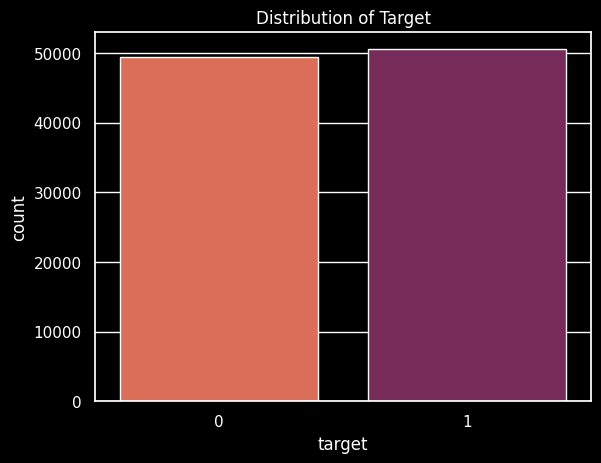

In [22]:
print("Value Distubution")
print(df['target'].value_counts())
print("-----------------------------------------")
print("Percentage Distubution")
print(df['target'].value_counts(normalize=True)*100)

# Plot the target variable distribution i.e. actual imbalanced values
sns.countplot(x='target', data=df, palette='rocket_r')
plt.title('Distribution of Target')
plt.show()

### ***Observation***

#### The DATASET is BALANCED, almost 50% is the probability of System Threat

## Outliers

In [23]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features:", numerical_features, " ", df.shape)

Numerical Features: ['RealTimeProtectionState', 'IsPassiveModeEnabled', 'AntivirusConfigID', 'NumAntivirusProductsInstalled', 'NumAntivirusProductsEnabled', 'HasTpm', 'CountryID', 'CityID', 'GeoRegionID', 'LocaleEnglishNameID', 'OSBuildNumber', 'OSProductSuite', 'IsSystemProtected', 'SMode', 'IEVersionID', 'FirewallEnabled', 'EnableLUA', 'OEMNameID', 'OEMModelID', 'ProcessorCoreCount', 'ProcessorManufacturerID', 'ProcessorModelID', 'PrimaryDiskCapacityMB', 'SystemVolumeCapacityMB', 'HasOpticalDiskDrive', 'TotalPhysicalRAMMB', 'PrimaryDisplayDiagonalInches', 'PrimaryDisplayResolutionHorizontal', 'PrimaryDisplayResolutionVertical', 'InternalBatteryNumberOfCharges', 'OSBuildNumberOnly', 'OSBuildRevisionOnly', 'OSInstallLanguageID', 'OSUILocaleID', 'IsPortableOS', 'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled', 'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable', 'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier', 'target']   (100000, 73)


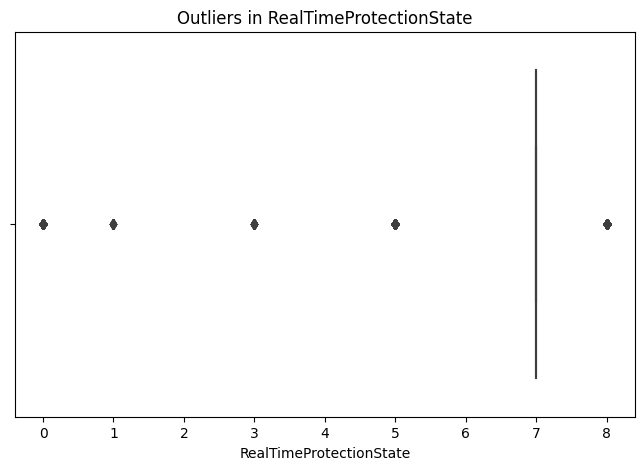

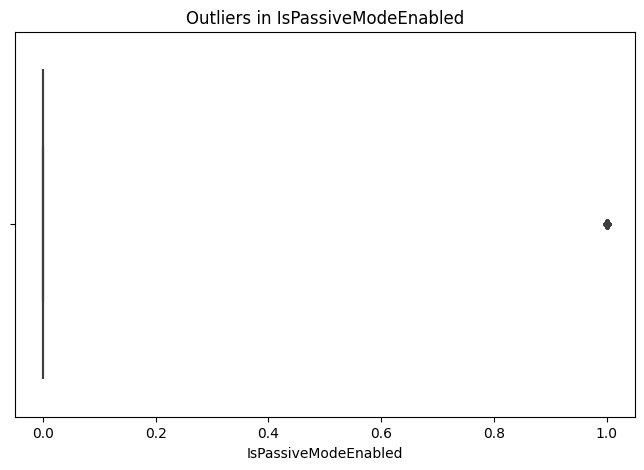

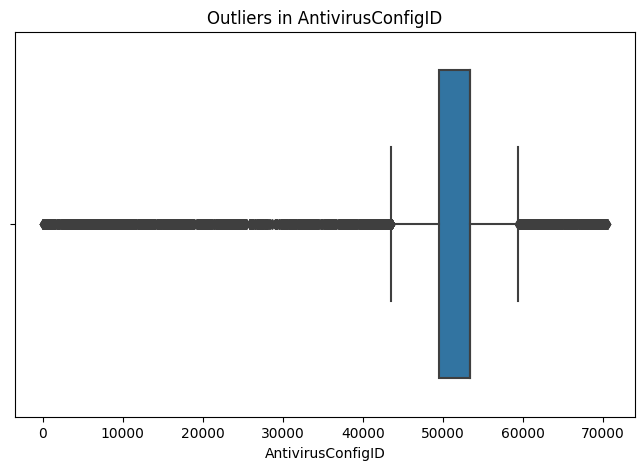

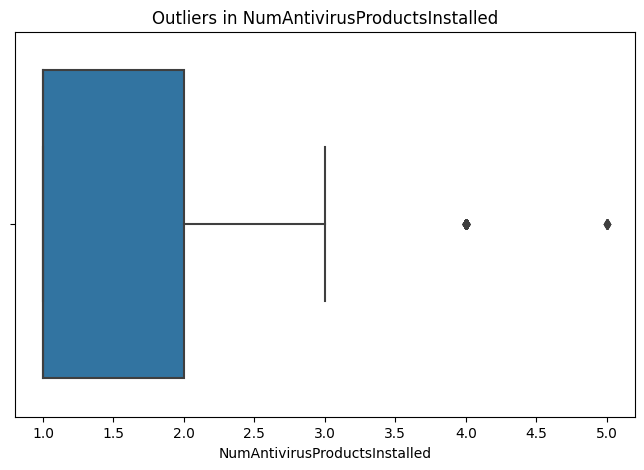

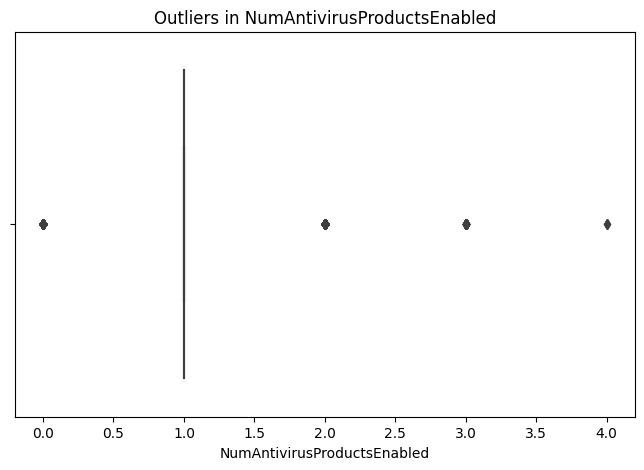

In [24]:
# Box plots for numerical features to detect outliers
plt.style.use('default') 
for col in numerical_features[:5]:  # Limiting to first 5 features for visualization
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=col)
    plt.title(f"Outliers in {col}")
    plt.show()

### ***Observations:***

#### 1️⃣ AntivirusConfigID

#### 1. Highly spread values with a wide range (0 to ~70,000).
#### 2. Possible outliers beyond the whiskers at both ends.

#### Insights:

#### 1. This might be a categorical or hashed identifier rather than a meaningful numerical feature.
#### 2. If it's a categorical ID, consider treating it as a categorical feature instead of numerical.

#### 2️⃣ NumAntivirusProductsInstalled


#### 1. Most values are between 1 and 3.
#### 2. A few outliers at 4 and 5 antivirus products installed.

#### Insights:

#### 1. Having multiple antivirus products installed might indicate potential security concerns (e.g., conflicts between software).
#### 2. Consider creating a binary feature: HasMultipleAntivirus = 1 if NumAntivirusProductsInstalled > 1, else 0.

In [25]:
# # Outlier capping function
# def cap_outliers(data, cols):
#     for col in cols:
#         Q1 = data[col].quantile(0.25)
#         Q3 = data[col].quantile(0.75)
#         IQR = Q3 - Q1

#         # Define the outlier boundaries
#         cap_upper = Q3 + 1.5 * IQR
#         cap_lower = Q1 - 1.5 * IQR

#         # Apply capping
#         data[col] = data[col].apply(lambda x: cap_upper if x > cap_upper else (cap_lower if x < cap_lower else x))    
#     return data

# # Apply outlier capping on numerical features
# df = cap_outliers(df, numerical_features)
# print("Outliers handled successfully!")

#### Since reducing the outliers is decreasing the accuracy score, I have commented the code.
#### Possible reason could be- the outliers present in the dataset are minimal, and are import in classification task. They aren't noise.

## ***2. Preprocessing***

### ***Working on Duplicates***

In [26]:
#Identify duplicates
print("Number of duplicates: ",df.duplicated().sum())

#Remove duplicates
df = df.drop_duplicates()
print("Duplicates dropped !")

print(df.duplicated().sum(), " ", df.shape)

Number of duplicates:  165
Duplicates dropped !
0   (99835, 73)


### ***Working with NaN values***

In [27]:
# Get the list of columns that have any NaN values
cols_with_nan = df.columns[df.isna().any()].tolist()
print("Columns with any NaN values:")
print(cols_with_nan, "    Total:", len(cols_with_nan))

Columns with any NaN values:
['RealTimeProtectionState', 'AntivirusConfigID', 'NumAntivirusProductsInstalled', 'NumAntivirusProductsEnabled', 'CityID', 'IsSystemProtected', 'SMode', 'IEVersionID', 'FirewallEnabled', 'EnableLUA', 'OEMNameID', 'OEMModelID', 'ProcessorCoreCount', 'ProcessorManufacturerID', 'ProcessorModelID', 'PrimaryDiskCapacityMB', 'PrimaryDiskType', 'SystemVolumeCapacityMB', 'TotalPhysicalRAMMB', 'ChassisType', 'PrimaryDisplayDiagonalInches', 'PrimaryDisplayResolutionHorizontal', 'PrimaryDisplayResolutionVertical', 'InternalBatteryNumberOfCharges', 'OSInstallLanguageID', 'FirmwareManufacturerID', 'FirmwareVersionID', 'IsVirtualDevice', 'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier', 'DateOS']     Total: 32


In [28]:
for col in cols_with_nan:
    print(col," ",df[col].unique())
    print('-------------------------')

RealTimeProtectionState   [ 7.  0.  8. nan  5.  3.  1.]
-------------------------
AntivirusConfigID   [53447. 46413. 40466. ...  3410. 13207. 32922.]
-------------------------
NumAntivirusProductsInstalled   [ 1.  2.  3.  4. nan  5.]
-------------------------
NumAntivirusProductsEnabled   [ 1.  2.  0. nan  3.  4.]
-------------------------
CityID   [120232. 112854.  41759. ...  17227. 133133. 155850.]
-------------------------
IsSystemProtected   [ 1.  0. nan]
-------------------------
SMode   [ 0. nan  1.]
-------------------------
IEVersionID   [ 98. 137. 108. 117.  76.  94. 333. 135. 111.  96. 105.  53.  87.  74.
 114. 103.  nan 185.  90.  71. 107.  86.  41.  81. 323.  73.  78. 334.
 336. 163.  62. 335.  65.  82.  88.  68.  42.  84. 302.  92. 169.  39.
  85. 295.  52. 205. 186.  91.  49.  72. 327.  44.  63. 322. 307. 332.
 180. 199. 429. 326. 102. 194.  50. 201.  45.  46. 329. 182. 338. 190.
 337. 297.  51. 304.  47.  61. 364.  64.  66. 288. 196. 284. 325. 178.
 275. 306. 311. 309. 

### ***Observation:***
#### There are NaN values, but in some columns there exists 'UNKNOWN', 'Unknown', 'Unspecified'

In [29]:
for col in cols_with_nan:
    if pd.api.types.is_numeric_dtype(df[col]):
        # For numeric columns, fill missing values with the median
        df[col] = df[col].fillna(df[col].median())
    else:
        # For categorical columns, fill missing values with the mode
        df[col] = df[col].fillna(df[col].mode()[0])
        df[col] = df[col].replace(['UNKNOWN', 'Unknown', 'Unspecified'], df[col].mode()[0])  # Replace placeholders

# print("Sample of filled values for columns with NaN:")
# print(df[cols_with_nan].head())

for col in cols_with_nan:
    print(col," ",df[col].unique())
    print('-------------------------')

RealTimeProtectionState   [7. 0. 8. 5. 3. 1.]
-------------------------
AntivirusConfigID   [53447. 46413. 40466. ...  3410. 13207. 32922.]
-------------------------
NumAntivirusProductsInstalled   [1. 2. 3. 4. 5.]
-------------------------
NumAntivirusProductsEnabled   [1. 2. 0. 3. 4.]
-------------------------
CityID   [120232. 112854.  41759. ...  17227. 133133. 155850.]
-------------------------
IsSystemProtected   [1. 0.]
-------------------------
SMode   [0. 1.]
-------------------------
IEVersionID   [ 98. 137. 108. 117.  76.  94. 333. 135. 111.  96. 105.  53.  87.  74.
 114. 103. 185.  90.  71. 107.  86.  41.  81. 323.  73.  78. 334. 336.
 163.  62. 335.  65.  82.  88.  68.  42.  84. 302.  92. 169.  39.  85.
 295.  52. 205. 186.  91.  49.  72. 327.  44.  63. 322. 307. 332. 180.
 199. 429. 326. 102. 194.  50. 201.  45.  46. 329. 182. 338. 190. 337.
 297.  51. 304.  47.  61. 364.  64.  66. 288. 196. 284. 325. 178. 275.
 306. 311. 309. 318. 313. 331.  59.  48. 383. 371. 174. 153. 

#### 🔹 Conclusion

#### 1. There were missing values in both numerical and categorical columns.
#### 2. Some categorical features were stored as numerical IDs (e.g., AntivirusConfigID, ProcessorModelID).
#### 3. Some binary categorical features had NaNs, which may indicate missing data or an unknown state (e.g., IsGamer, IsVirtualDevice).

## ***Separate features and target***

In [30]:
# Separate features and target
X = df.drop(['target'], axis=1)  # Exclude 'target'
y = df['target']

## ***Pipeline***

In [31]:
# Identify numerical and categorical features
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Handle missing values & scaling for numerical features
num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', PowerTransformer(method='yeo-johnson'))
])

# Handle categorical features (encoding + missing values)
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ],
    remainder= 'passthrough'
)

#### Had tried- 
#### 1. PoynomialFeature+Feature Ratio- doing polynomial feature transformation with and without feature ratio, is just reducing my accuracy, hence had to remove it
#### 2. In numerical tranformations, I replaced SimpleImputer with KNNImputer and StandardScaler with PowerTransformer, for better results
#### 3. Used OrdinalEncoder instead of LabelEncoder for increase in efficient encoding results
#### 4. Avoided OneHotEncoding due to large dataset size (many Features)
#### 5. Finally passed num_tranformer and cat_transformer into the Column tranformer
#### 6. Had tried PCA, didn't work('pca', PCA(n_components=40, whiten=True, svd_solver='randomized')) , ('pca', PCA(n_components=0.95, svd_solver='full'))# Retain 95% variance

In [32]:
# Feature Selection (Adjust k value as needed)
k_best = SelectKBest(score_func=f_classif, k=58)  # Adjust k based on performance

#### Note: keeping lower values of K i.e between : `(15,57)` is simply giving lower accuracy

## ***Spliting the dataset***

In [33]:
# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

#### Using `stratify=y` is reducing the accuracy score.

# ***Model***

### ***Used 3 models:***

##### 1. RandomForestClassifier -- 0.61460
##### 2. AdaBoostClassifier -- 0.62020
##### 3. XGBClassifier -- 0.63550

#### 1. Tried out SGDClassifier, and Esembler(RandomForest, SGDClassfier)
#### 2. Even worked on Esembler(AdaBoost, XGBClassifier)
#### 3. But these didn't give a good accuracy

## ***1. Initialize and train the model***

### **Model_1: Random Forest**

In [34]:
# model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
# model.fit(X_train, Y_train)

### **Model_2: AdaBoost**

In [35]:
# adaboost = AdaBoostClassifier(random_state=42)
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.2, 0.7, 1.2],
#     'algorithm': ['SAMME']
# }
# grid_search = GridSearchCV(adaboost, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
# grid_search.fit(X_train, Y_train)

In [36]:
# # Best Model
# model = grid_search.best_estimator_
# print("Best Parameters:", grid_search.best_params_)

### Model_3: XGBClassifier

In [37]:
# Define model
model = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', k_best),

    ('classifier', XGBClassifier(
        n_estimators=350,   # More boosting rounds
        max_depth=5,        # Shallower trees for better generalization
        learning_rate=0.05, # Lower LR for stable learning
        subsample=0.8,      # Uses 90% of data per tree
        colsample_bytree=0.9, # Uses 90% of features per tree
        gamma=2,            # Regularization to prevent unnecessary splits
        min_child_weight=3, # Prevents splitting on small noisy data
        reg_alpha=0.5,      # L1 regularization to reduce overfitting
        reg_lambda=1,       # L2 regularization for stability
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    )
])

In [38]:
# Fit model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   PowerTransformer())]),
                                                  ['RealTimeProtectionState',
                                                   'IsPassiveModeEnabled',
                                                   'AntivirusConfigID',
                                                   'NumAntivirusProductsInstalled',
                                                   'NumAntivirusProductsEnabled',
                                                   'HasTpm', 'CountryID',
                                                   'CityID', 'GeoRegionID',
                                                   'Loca...
                               feature_types=None, gamma=2, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=350,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=42, ...))])

## ***2. Evaluate the model***

In [39]:
# Predictions
y_pred = model.predict(X_val)

In [40]:
# Evaluate performance
accuracy = accuracy_score(y_val, y_pred)
print('Validation Accuracy:', accuracy) # Validation Accuracy: 0.633613782051282

Validation Accuracy: 0.633613782051282


In [41]:
# Detailed classification report
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.58      0.61      7402
           1       0.63      0.68      0.65      7574

    accuracy                           0.63     14976
   macro avg       0.63      0.63      0.63     14976
weighted avg       0.63      0.63      0.63     14976



## ***3. Model Testing***

## Feature Importance PLot(For XGBoost)

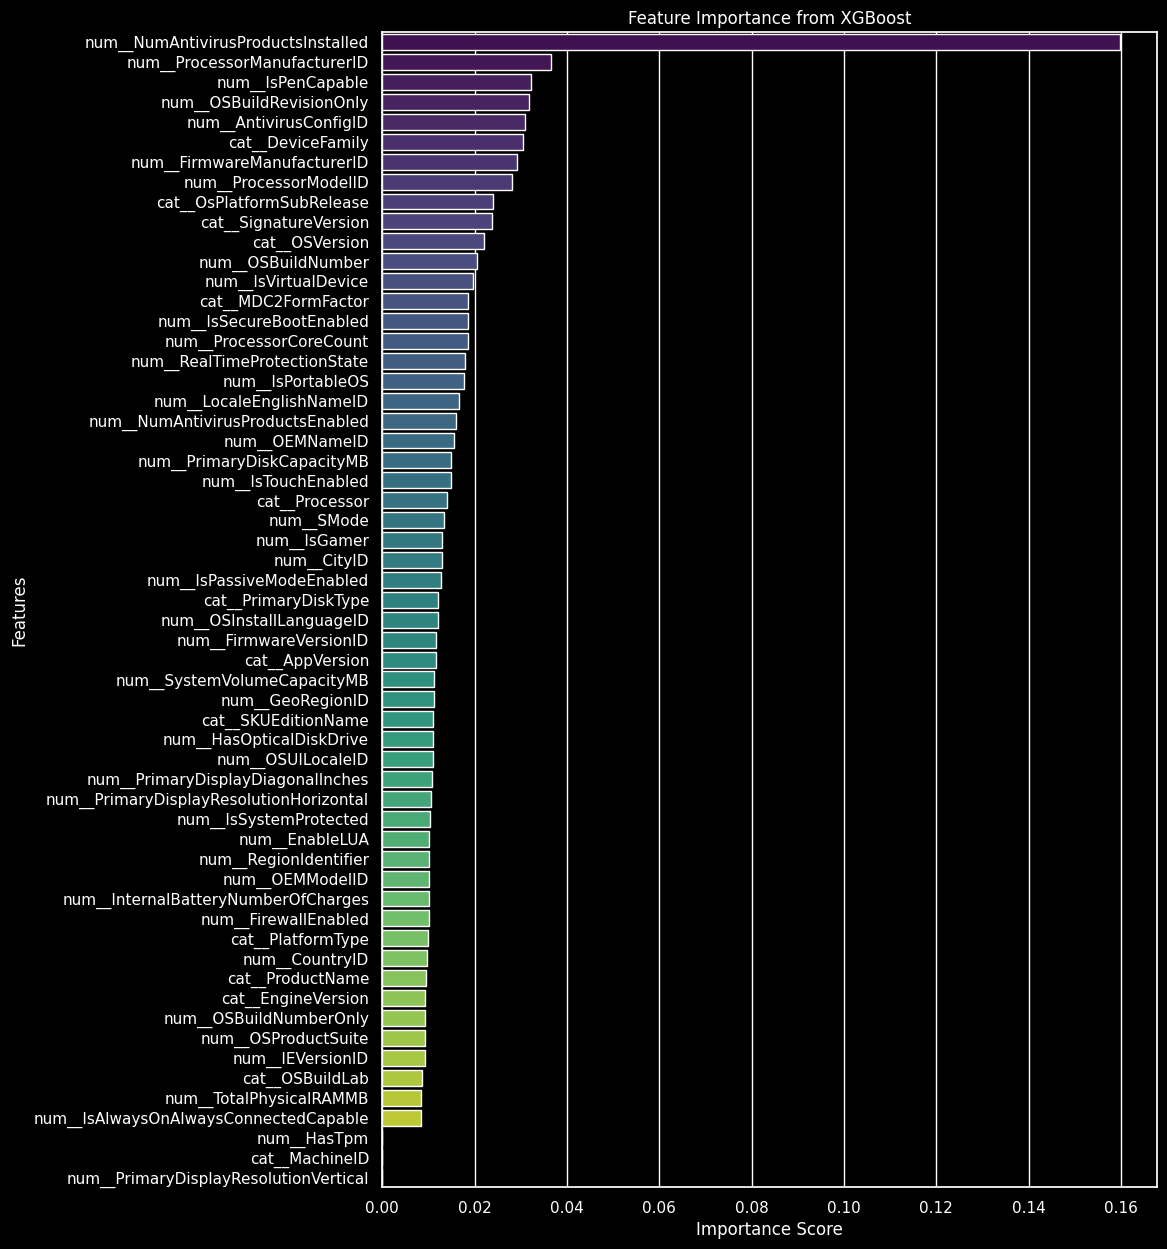

In [42]:
# Setting the theme
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# For AdaBoostClassifier and RandomForestClassifier
# importances = model.feature_importances_
# features = X_train.columns
# features

# For XGBClassifier
# Extract trained classifier from the pipeline
classifier = model.named_steps['classifier']

# Get feature importances
importances = classifier.feature_importances_

# Get selected feature names after preprocessing
features = model.named_steps['preprocessing'].get_feature_names_out()
# Ensure the lengths match
if len(importances) != len(features):
    # print(f"Warning: Mismatch in feature count! ({len(importances)} importances vs {len(features)} features)")
    print(' ')
    min_len = min(len(importances), len(features))
    importances = importances[:min_len]  # Trim to match
    features = features[:min_len]

# Sort features by importance
sorted_idx = np.argsort(importances)[::-1]
importances = importances[sorted_idx]
features = np.array(features)[sorted_idx]

# Plot feature importance
plt.figure(figsize=(10, 15))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance from XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### ***Key Observations from the Plot:***

### Highly Important Features
  
##### 1. NumAntivirusProductsInstalled is the most influential feature.
##### 2. AntivirusConfigID and NumAntivirusProductsEnabled also play a crucial role.
##### 3. LocaleEnglishNameIdentifier and TotalPhysicalRAMMB contribute significantly.

### Moderately Important Features

##### 1. PrimaryDisplayDiagonalInches, PrimaryDisplayResolutionHorizontal  affect predictions.
##### 2. IsGamer, IsAlwaysOnAlwaysConnectedCapable, and RegionIdentifier have a noticeable impact.

### Least Important Features

##### 1. Features like ProductName, BetaUser, and OSBuildLab contribute very little.
##### 2. Features like MachineID,PrimaryDisplayResolutionVertical, HasTpm have no importance_score.

In [43]:
# Generate Predictions
Y_test_pred = model.predict(X_test)